# Customer Churn Prediction  
## Modeling and Evaluation

The goal of this step is to **build and evaluate machine learning models** for predicting customer churn.
This process involves splitting the preprocessed dataset into training and testing sets, training multiple
classification models, evaluating their performance using appropriate metrics, addressing class imbalance,
and selecting the most suitable model for final deployment.


### Step 1: Import Required Libraries
In this step, we import the essential Python libraries required for data modeling and evaluation.

In [83]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)


### Step 2: Load Preprocessed Data

In this step, we load the preprocessed datasets produced in the preprocessing phase.

These files contain the training and testing splits for both features (X) and the target variable (y),
so we can proceed directly to model training.


### 2.1 Load Preprocessed Data:

In [84]:
# Load feature datasets
X_train = pd.read_csv("data/processed/X_train.csv")
X_test  = pd.read_csv("data/processed/X_test.csv")

# Load target datasets
y_train = pd.read_csv("data/processed/y_train.csv")
y_test  = pd.read_csv("data/processed/y_test.csv")


### 2.2 Dataset Shape Verification:

We verify the shapes of the loaded datasets to ensure that:
- The number of rows in X matches the number of rows in y for both train and test sets
- The feature dimensions are consistent across splits


In [85]:
# feature dataset shape
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# target dataset shape
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634, 1)
y_test shape: (1409, 1)


**Shape Verification Summary:**

- The number of samples in `X_train` matches `y_train`, and **similarly** for the test set, confirming that features and target variables are correctly aligned.
- The **training set** contains 5,634 samples, while the **test set** contains 1,409 samples, reflecting an approximate **80/20** split.
- The **feature matrix** includes 30 features, which remain consistent across both training and testing datasets.

These results confirm that the data has been **loaded correctly** and is ready for model training.


### 2.3 Converting y to a Series:

Some scikit-learn models and evaluation functions expect the target variable (y) to be a **1D array/Series**.

Therefore, we convert y_train and y_test from a single-column DataFrame to a Series.


In [86]:
# Converting y to a Series
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [87]:
# Verify conversion
print("y_train type:", type(y_train))
print("y_test type:", type(y_test))


y_train type: <class 'pandas.core.series.Series'>
y_test type: <class 'pandas.core.series.Series'>


**Conversion Verification:**

After applying the `squeeze()` operation, both `y_train` and `y_test` were successfully converted from
single-column DataFrames to pandas Series objects.

This confirms that the target variable is now in a 1-dimensional format, which is required by most scikit-learn models and evaluation functions.


## Step 3: Baseline Model

In this step, we build a simple baseline classifier to establish a reference performance for customer churn prediction.
The baseline model provides a benchmark that allows us to evaluate whether more complex models offer meaningful improvements.

### 3.1 Baseline Model Rationale 

`Logistic Regression` is selected as the baseline model because customer churn prediction is a **binary**
classification problem. This model provides a simple, interpretable, and widely used baseline that
establishes a reference performance level. Any more complex model should demonstrate an improvement
over this baseline to justify its use.


### 3.2 Train Baseline Logistic Regression

In [88]:
# Suppress convergence warnings for cleaner notebook output.
# These warnings do not affect model correctness and are expected in baseline models
# trained without feature scaling.
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [89]:
# Train the baseline Logistic Regression model
# max_iter is set to ensure model convergence during optimization
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_baseline = baseline_model.predict(X_test)


**Note:**  
Although the `max_iter` parameter was increased, a convergence warning was observed.
This is expected since the baseline model was trained without feature scaling.
The purpose of this baseline is to establish a reference performance, and further improvements
will be explored in subsequent steps.


### 3.3 Baseline Model Evaluation

We evaluate the baseline model using standard classification metrics to assess its initial performance.
These metrics will later be used to compare the baseline against more advanced models.


In [90]:
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline))
print("Recall:", recall_score(y_test, y_pred_baseline))
print("F1-score:", f1_score(y_test, y_pred_baseline))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_baseline))


Accuracy: 0.8041163946061036
Precision: 0.6540880503144654
Recall: 0.5561497326203209
F1-score: 0.6011560693641619

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



**Baseline Model Evaluation – Results Interpretation**

The baseline `Logistic Regression` model achieved an overall **accuracy of approximately 80%**, indicating that it correctly classified the majority of customers in the test set. However, accuracy alone is not sufficient to evaluate churn prediction performance due to class imbalance.

For the **non-churn class (0)**, the model demonstrates strong performance, achieving a **precision of 0.85** and a **recall of 0.89**, which means that most non-churning customers are correctly identified.

In contrast, the model shows weaker performance for the **churn class (1)**. While the **precision is 0.65**, indicating that predicted churn cases are often correct, the **recall is relatively low at 0.56**. This means that a significant number of actual churn customers are not detected by the model (false negatives).

The **F1-score for the churn class is 0.60**, reflecting the trade-off between precision and recall. This moderate score highlights the limitation of the baseline model in capturing churn behavior effectively.

Overall, these results confirm that while Logistic Regression provides a reasonable baseline, it struggles to identify churn customers accurately. This motivates the use of more advanced models and class imbalance handling techniques in subsequent steps to improve churn detection performance.


### 3.4 Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions made by the baseline model.


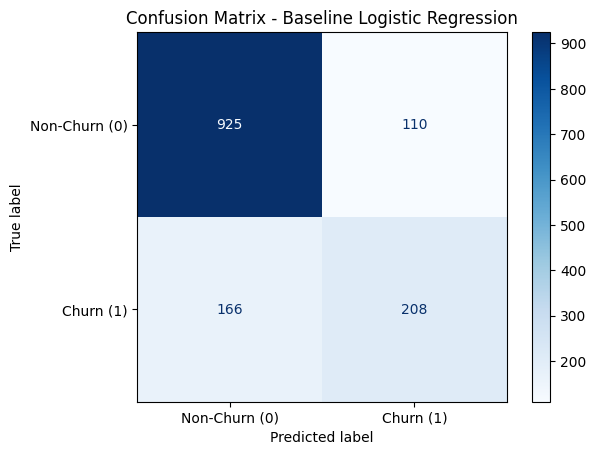

In [91]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    cmap="Blues",
    display_labels=["Non-Churn (0)", "Churn (1)"],
    values_format="d"
)

plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()



**Confusion Matrix Interpretation**

The confusion matrix illustrates the distribution of correct and incorrect predictions made by the baseline Logistic Regression model.

- **True Negatives (TN = 925):**  
  Customers who did not churn and were correctly predicted as non-churn. This indicates that the model performs well in identifying stable customers.

- **False Positives (FP = 110):**  
  Customers who did not churn but were incorrectly predicted as churn. These represent unnecessary churn alerts but are generally less costly than missed churn cases.

- **False Negatives (FN = 166):**  
  Customers who actually churned but were predicted as non-churn. This is the most critical error in churn prediction, as these customers are missed and no retention action would be taken.

- **True Positives (TP = 208):**  
  Customers who churned and were correctly identified by the model.

Overall, the confusion matrix confirms that the baseline model is more effective at identifying non-churn customers than churn customers. The relatively high number of false negatives highlights the need for improved modeling techniques and class imbalance handling in subsequent steps to better capture churn behavior.


**Baseline Model Summary**

The baseline `Logistic Regression` model achieves an overall accuracy of approximately **80%**. However, its recall for the churn class (1) is relatively **low (~56%)**, indicating that a noticeable number of churn customers are **missed**.

This limitation motivates the use of more advanced models and class imbalance handling techniques in the next steps to improve churn detection performance.


## Step 4: Machine Learning Models Training and Comparison


In this step, We **train and compare** multiple machine learning models to evaluate their ability to predict customer churn.
The goal is to assess the **natural performance** of different algorithms under the same data conditions before applying any optimization techniques.

At this stage, no class imbalance handling or feature optimization is applied to ensure a fair and unbiased comparison.
The results of this step will guide the selection of the most promising model, which will later be enhanced to improve churn detection performance.

### 4.1 Models Selection Rationale

we train multiple machine learning models that are commonly used in customer churn prediction.
These models represent different learning paradigms, allowing us to compare their behavior and performance under the same data conditions.

The selected models are:
- **Decision Tree** (rule-based)
- **Random Forest** (ensemble-based)
- **Support Vector Machine (SVM)** (margin-based)
- **K-Nearest Neighbors (KNN)** (distance-based)

### 4.2 Model Definitions 

In [92]:
models = {
    "Logistic Regression (Baseline)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "Random Forest": RandomForestClassifier(random_state=42),
    
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}


**Note :**
`Logistic Regression`and `SVM` and `KNN` require feature **scaling** due to their reliance on distance and margin calculations.

**Only minimal scaling** is applied to ensure stable training, without introducing optimization bias.


### 4.3 Model Training and Prediction

In [93]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score) if y_score is not None else None
    })



### 4.4 Models Performance Comparison 

In [94]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="F1-score", ascending=False)
    .reset_index(drop=True)
)
# Models are ranked based on their F1-score (higher is better).
results_df.insert(0, "Rank", results_df.index + 1)
results_df


,Rank,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,1,Logistic Regression (Baseline),0.806955,0.658385,0.566845,0.609195,0.841585
1,2,SVM (RBF),0.792761,0.644366,0.489305,0.556231,0.796050
2,3,Random Forest,0.786373,0.623729,0.491979,0.550075,0.825081
3,4,KNN,0.747339,0.525281,0.500000,0.512329,0.771797
4,5,Decision Tree,0.741661,0.513889,0.494652,0.504087,0.662297


**Results Interpretation (Models Comparison)**

The table above compares the baseline `Logistic Regression` model with four additional machine learning classifiers
(`Decision Tree`, `Random Forest`, `SVM`, and `KNN`), all evaluated using the same preprocessed dataset and the same train/test split.
This ensures a fair comparison where performance differences are primarily due to the learning algorithms themselves.

**Key Observations**

Best performing model (based on F1-score): `Logistic Regression` (Baseline)
The baseline Logistic Regression achieved the highest F1-score (~0.61) and the highest recall (~0.57) among all tested models, indicating a better balance between precision and recall for identifying churn customers under baseline conditions.

Random Forest shows competitive performance, achieving a strong ROC-AUC (~0.83), which indicates good overall class separation ability. However, its recall and F1-score remain lower than the baseline Logistic Regression.

SVM (RBF) performs reasonably well but exhibits lower recall, suggesting that it misses a larger portion of churn customers compared to Logistic Regression.

KNN and Decision Tree demonstrate weaker overall performance, particularly in F1-score and ROC-AUC, indicating limited effectiveness under the current unoptimized setting.

**What this means**

Although several models achieve similar accuracy values, accuracy alone is not sufficient for churn prediction due to class imbalance.
Greater emphasis is placed on Recall, F1-score, and ROC-AUC, as failing to identify churn customers (false negatives) can be costly for the business.

**Conclusion**

In this step, multiple machine learning models were evaluated under identical baseline conditions without applying class imbalance handling or hyperparameter tuning.
Interestingly, the baseline Logistic Regression model outperformed more complex models, highlighting that model complexity alone does not guarantee better churn detection.

These results indicate that addressing class imbalance is likely more impactful than changing the algorithm itself.
Therefore, in Step 5, we will focus on applying class imbalance handling techniques to improve churn detection performance, with a particular emphasis on increasing recall for the churn class (1).

## Step 5: Handling Class Imbalance and Model Improvement

### 5.1 Why Handle Class Imbalance?

The dataset exhibits class imbalance, where **non-churn customers** significantly outnumber **churn customers**.
This imbalance causes machine learning models to be **biased** toward the majority class, resulting in **high accuracy** but **low recall** for the churn class.

Since the business cost of **missing churn customers** is high, improving recall for the minority class becomes a **key objective**.


### 5.2 Selected Resampling Techniques

**Techniques:**

1- Random Under-Sampling

2- Random Over-Sampling

3- SMOTE

These techniques allow us to evaluate how different imbalance handling strategies affect model performance, particularly recall and F1-score.

### 5.3 Applying Resampling Techniques with the Selected Model

After evaluating multiple models in Step 4, `Logistic Regression` was selected as the baseline model due to its **superior performance** in terms of F1-score and recall under unoptimized conditions.

In this step, we apply **different class imbalance handling techniques** to the training data and retrain the selected model to assess how each strategy impacts **churn** detection performance.

**To ensure a fair comparison:**

Resampling is applied only to the training set.

The same test set is used for evaluation.

The same evaluation metrics are maintained.

**The following resampling techniques are applied:**

1- Random Under-Sampling

2- Random Over-Sampling

3- SMOTE

Model performance is evaluated using **Recall, F1-score, and ROC-AUC**, with particular emphasis on improving recall for the **churn class (1)**, as failing to identify churn customers is **costly** from a business perspective.


In [95]:
# 5.3 Applying Resampling Techniques (Train Only) with Logistic Regression

import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Define resampling strategies
resampling_strategies = {
    "No Resampling (Baseline)": None,
    "Random Under-Sampling": RandomUnderSampler(random_state=42),
    "Random Over-Sampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
}

results = []

for name, sampler in resampling_strategies.items():

    if sampler is None:
        pipe = Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=42))
        ])
    else:
        pipe = Pipeline(steps=[
            ("sampler", sampler),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=42))
        ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Technique": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(by="F1-score", ascending=False)
    .reset_index(drop=True)
)

results_df


,Technique,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Under-Sampling,0.742370,0.509532,0.786096,0.618297,0.842370
1,SMOTE,0.782825,0.580569,0.655080,0.615578,0.835214
2,Random Over-Sampling,0.733854,0.499151,0.786096,0.610592,0.841587
3,No Resampling (Baseline),0.806955,0.658385,0.566845,0.609195,0.841585


**Results Interpretation (Resampling Comparison)**

Applying resampling on the training set **improved** the model's ability to detect churn customers.

Compared to no resampling, all techniques **increased** recall noticeably (fewer false negatives), while accuracy and precision **decreased** due to predicting more churn cases.

Although **Random Under-Sampling** achieved a slightly higher F1-score, **SMOTE** provided a better overall balance between Precision, Recall, and Accuracy while preserving all majority-class samples by generating synthetic minority examples instead of removing existing data. Therefore, **SMOTE** was selected as the resampling technique for the subsequent model optimization.

These results reinforce the decision to prioritize **Recall** and **F1-score** due to the **high business cost** associated with failing to identify customers who are likely to churn.



              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1035
           1       0.58      0.66      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



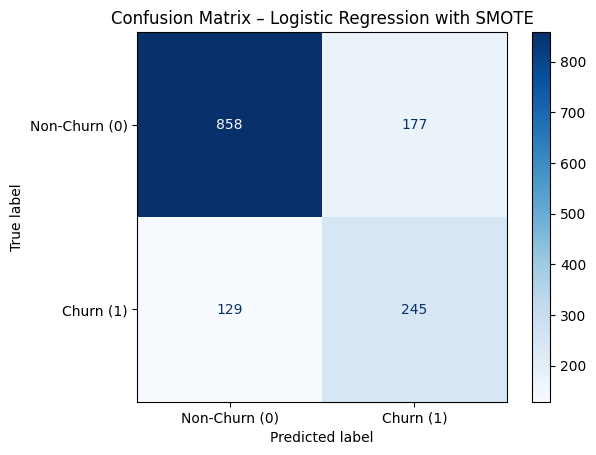

In [96]:
# 5.4 Confusion Matrix (Best Technique: SMOTE)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Build SMOTE + scaled Logistic Regression pipeline
smote_clf = Pipeline(steps=[
    ("sampler", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Train on training set only
smote_clf.fit(X_train, y_train)

# Predict on test set
y_pred_smote = smote_clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Churn (0)", "Churn (1)"]
)
disp.plot(cmap="Blues", values_format="d")
disp.ax_.set_title("Confusion Matrix – Logistic Regression with SMOTE")


# classification report
print(classification_report(y_test, y_pred_smote))



**Confusion Matrix Interpretation (SMOTE)**

The confusion matrix demonstrates the performance of Logistic Regression after applying SMOTE.

- The model correctly identified **858 non-churn customers (True Negatives)**, maintaining strong performance for the majority class.
- It successfully detected **245 churn customers (True Positives)**.
- The number of **False Negatives (129)** decreased compared to the baseline model, indicating improved recall for the churn class.
- Although **False Positives (177)** increased, this trade-off is acceptable in churn prediction, where missing a churn customer is more costly than incorrectly flagging a loyal one.

Overall, **SMOTE** improves the model’s ability to detect churn customers by reducing missed churn cases and increasing recall for class (1).


**Conclusion**

In this step, different class imbalance handling techniques were evaluated using `Logistic Regression` as the baseline model.

The results show that applying resampling techniques improves the model’s ability to detect churn customers. While overall accuracy decreased slightly, both Recall and F1-score improved compared to the baseline model.

Among the evaluated techniques, **SMOTE** provided a **strong balance** between Precision and Recall, making it the most suitable strategy for improving churn detection performance.

These findings confirm that handling class imbalance is essential for this business problem. 
Therefore, **SMOTE** will be adopted in the next stage to further enhance model performance through advanced modeling and hyperparameter tuning.


## Step 6: Model Optimization & Advanced Modeling

### 6.1 Hyperparameter Tuning – Logistic Regression (with SMOTE)

In [97]:
# 6.1 Hyperparameter Tuning – Logistic Regression (with SMOTE)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# 1) Build pipeline: SMOTE -> Scaling -> Logistic Regression
pipe_lr = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# 2) Define parameter grid 
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"] 
}

# 3) Grid Search (focus on F1-score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

# 4) Train
grid_lr.fit(X_train, y_train)

# 5) Best model
best_lr_model = grid_lr.best_estimator_
print("Best Parameters (LR):", grid_lr.best_params_)
print("Best CV F1-score (LR):", grid_lr.best_score_)



Best Parameters (LR): {'clf__C': 0.1, 'clf__penalty': 'l2'}
Best CV F1-score (LR): 0.6131523072198247



Test Results (Tuned Logistic Regression + SMOTE):
Accuracy : 0.7806955287437899
Precision: 0.5727069351230425
Recall   : 0.6844919786096256
F1-score : 0.6236297198538368
ROC-AUC  : 0.8286057506006355


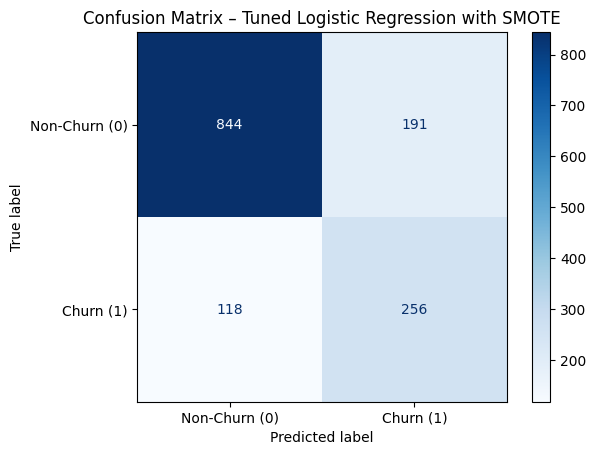


Classification Report (LR):
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1035
           1       0.57      0.68      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409



In [98]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# 6) Evaluate on test set
y_pred_lr = best_lr_model.predict(X_test)
y_score_lr = best_lr_model.predict_proba(X_test)[:, 1]

print("\nTest Results (Tuned Logistic Regression + SMOTE):")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_score_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Churn (0)", "Churn (1)"]
)

disp.plot(cmap="Blues", values_format="d")
disp.ax_.set_title("Confusion Matrix – Tuned Logistic Regression with SMOTE")

plt.show()

# classification report
print("\nClassification Report (LR):")
print(classification_report(y_test, y_pred_lr))

**Results Interpretation – Tuned Logistic Regression with SMOTE**

Hyperparameter tuning was conducted using **GridSearchCV with 5-fold cross-validation**, optimizing the model based on the **F1-score**. The best configuration was **C = 0.1 with L2 regularization**.

On the test set, the tuned model achieved **Accuracy = 0.78, Precision = 0.57, Recall = 0.68, F1-score = 0.62, and ROC-AUC = 0.83**. These results indicate improved churn detection by prioritizing **Recall and F1-score**, which is important in churn prediction where missing churners can be costly.

Overall, combining **SMOTE with hyperparameter tuning** strengthened the model’s ability to identify churn customers while maintaining stable overall performance.

### 6.2 Advanced Model: XGBoost (with SMOTE)


Test Results (XGBoost + SMOTE):
Accuracy : 0.7707594038325053
Precision: 0.5611510791366906
Recall   : 0.6256684491978609
F1-score : 0.5916561314791403
ROC-AUC  : 0.832507943889018


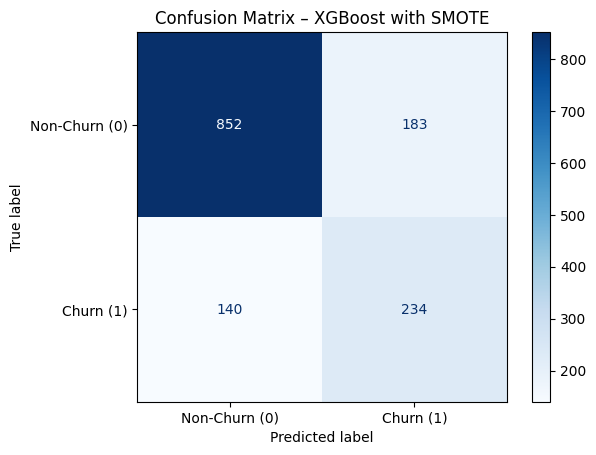


Classification Report (XGB):
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.77      1409



In [99]:
# 6.2 Advanced Model: XGBoost (with SMOTE)

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# 1) Build pipeline: SMOTE -> XGBoost
pipe_xgb = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ))
])

# 2) Train (train only)
pipe_xgb.fit(X_train, y_train)

# 3) Predict (test)
y_pred_xgb = pipe_xgb.predict(X_test)
y_score_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

# 4) Evaluation on test set
print("\nTest Results (XGBoost + SMOTE):")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_score_xgb))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Churn (0)", "Churn (1)"]
)

disp.plot(cmap="Blues", values_format="d")
disp.ax_.set_title("Confusion Matrix – XGBoost with SMOTE")

plt.show()

# Classification Report
print("\nClassification Report (XGB):")
print(classification_report(y_test, y_pred_xgb))


**Results Interpretation – XGBoost (with SMOTE)**

**XGBoost** was trained using an imbalanced-learn pipeline that applies **SMOTE** only to the training data, preventing data leakage while addressing class imbalance.

On the test set, the model achieved **Accuracy = 0.77, Precision = 0.56, Recall = 0.63, F1-score = 0.59, and ROC-AUC = 0.83**, indicating good overall class separation performance.

From the confusion matrix, the model correctly identified 234 churn customers, but missed 140 churn cases (false negatives). While the ROC-AUC remains strong, the **Recall and F1-score are lower** than the **tuned Logistic Regression model** in Section 6.1, meaning that under the current configuration, XGBoost detects fewer churn customers.

Overall, **XGBoost** demonstrates strong predictive capability, but additional hyperparameter tuning may be required to further improve Recall and F1-score for churn detection.

### 6.3 Advanced Model: Hyperparameter Tuning – XGBoost (with SMOTE)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters (XGB): {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Best CV F1-score (XGB): 0.628780983078925

Test Results (Tuned XGBoost + SMOTE):
Accuracy : 0.7565649396735273
Precision: 0.5308151093439364
Recall   : 0.713903743315508
F1-score : 0.6088939566704675
ROC-AUC  : 0.8333397917796895


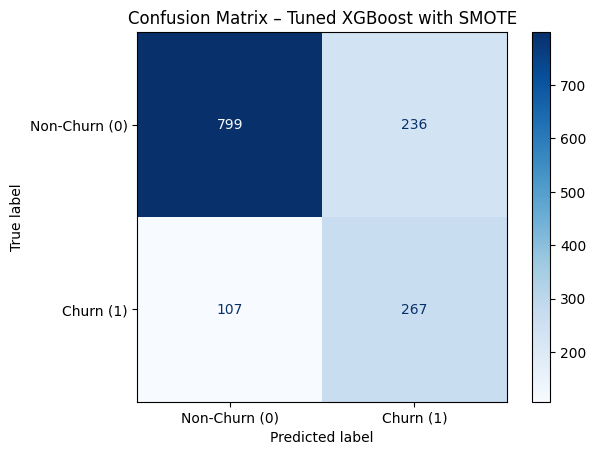


Classification Report (Tuned XGB):
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [100]:
# 6.3 Advanced Model: Hyperparameter Tuning – XGBoost (with SMOTE)

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# 1) Build pipeline: SMOTE -> XGBoost
pipe_xgb = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# 2) Define parameter grid
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [3, 4, 5],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

# 3) Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4) Grid Search (optimize F1-score)
grid = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# 5) Train
grid.fit(X_train, y_train)

print("Best Parameters (XGB):", grid.best_params_)
print("Best CV F1-score (XGB):", grid.best_score_)

# 6) Best model
best_xgb_model = grid.best_estimator_

# 7) Predict (test)
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_score_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

# 8) Evaluation
print("\nTest Results (Tuned XGBoost + SMOTE):")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall   :", recall_score(y_test, y_pred_xgb_tuned))
print("F1-score :", f1_score(y_test, y_pred_xgb_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_score_xgb_tuned))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred_xgb_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Churn (0)", "Churn (1)"]
)

disp.plot(cmap="Blues", values_format="d")
disp.ax_.set_title("Confusion Matrix – Tuned XGBoost with SMOTE")

plt.show()

# Classification Report
print("\nClassification Report (Tuned XGB):")
print(classification_report(y_test, y_pred_xgb_tuned))


**Results Interpretation – Tuned XGBoost (with SMOTE)**

Hyperparameter tuning was performed using **GridSearchCV** with **5-fold Stratified Cross-Validation**, optimizing the model based on the **F1-score** to better handle class imbalance.

**Best Parameters:**

n_estimators = 100  
max_depth = 3  
learning_rate = 0.05  
subsample = 0.8  
colsample_bytree = 0.8  

**Test Performance:**

Accuracy: 0.76  
Precision: 0.53  
Recall: 0.71  
F1-score: 0.61  
ROC-AUC: 0.83  

The tuned XGBoost model achieved **strong recall (~71%)**, indicating that the model successfully identifies a large proportion of churn customers. This is particularly important in churn prediction tasks where failing to detect potential churners can lead to significant business loss.

However, the model shows **moderate precision (~0.53)**, meaning that some non-churn customers are incorrectly predicted as churn. This trade-off is common in imbalanced classification problems where improving recall often reduces precision.

Although its **F1-score (~0.61)** is slightly lower than the tuned Logistic Regression model, the tuned XGBoost still demonstrates **strong overall discrimination ability**, as reflected in its **ROC-AUC score (~0.83)**.

The confusion matrix further supports this result, with only **107 false negatives**, indicating that most churn customers were successfully identified. From a business perspective, minimizing false negatives is critical because missing churn customers results in lost opportunities for retention actions, while false positives only lead to unnecessary retention efforts.

Overall, the tuned XGBoost model provides **competitive performance with strong recall**, making it a valuable candidate for the **final model selection stage**, particularly when minimizing missed churn cases is a priority.

### 6.4 Final Model Selection - Model Comparison

In [101]:
# 6.4 Model Comparison Table

comparison_results = []

# Tuned Logistic Regression
comparison_results.append({
    "Model": "Tuned Logistic Regression + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_score_lr)
})

# XGBoost
comparison_results.append({
    "Model": "XGBoost + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1-score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_score_xgb)
})

# Tuned XGBoost
comparison_results.append({
    "Model": "Tuned XGBoost + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_xgb_tuned),
    "Precision": precision_score(y_test, y_pred_xgb_tuned),
    "Recall": recall_score(y_test, y_pred_xgb_tuned),
    "F1-score": f1_score(y_test, y_pred_xgb_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_score_xgb_tuned)
})

comparison_df = pd.DataFrame(comparison_results)

# Sort by F1-score
comparison_df = comparison_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Logistic Regression + SMOTE,0.780696,0.572707,0.684492,0.623630,0.828606
1,Tuned XGBoost + SMOTE,0.756565,0.530815,0.713904,0.608894,0.833340
2,XGBoost + SMOTE,0.770759,0.561151,0.625668,0.591656,0.832508


Since the dataset is **imbalanced**, models were compared primarily using the **F1-score**, as it balances **precision and recall**.
The results show that `Tuned Logistic Regression + SMOTE` achieved the **highest F1-score**, indicating the best overall balance in detecting churn customers.
Although `Tuned XGBoost + SMOTE` achieved **higher recall**, its **lower precision reduced its F1-score**.
Therefore, `Tuned Logistic Regression + SMOTE` is **selected as the final model**, and the next section applies **threshold optimization** to further improve churn detection performance.

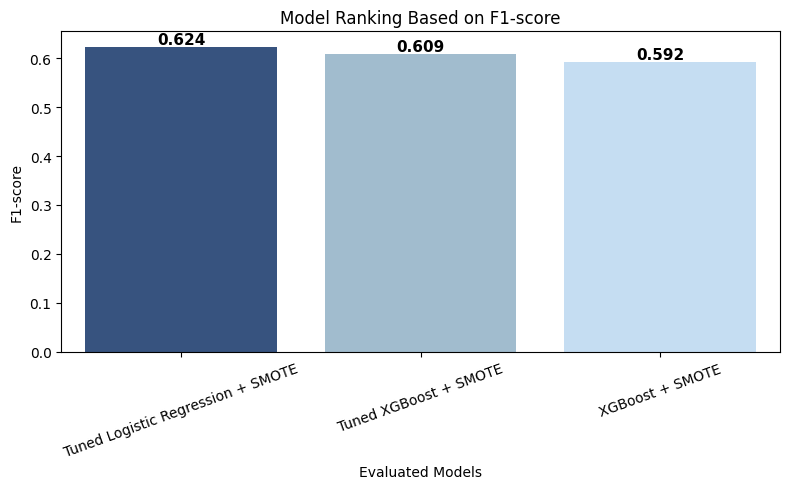

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

best_model = comparison_df.loc[comparison_df["F1-score"].idxmax(), "Model"]

colors = []
for model in comparison_df["Model"]:
    if model == best_model:
        colors.append("#2b518b") 
    else:
        colors.append("#9abdd5")  

if len(colors) > 2:
    colors[comparison_df.index[-1]] = "#bedef9"

ax = sns.barplot(
    data=comparison_df,
    x="Model",
    y="F1-score",
    hue="Model",
    palette=colors,
    legend=False
)

plt.title("Model Ranking Based on F1-score")
plt.ylabel("F1-score")
plt.xlabel("Evaluated Models")

plt.xticks(rotation=20)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.3f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

The bar chart illustrates the ranking of the evaluated models based on their **F1-scores**. 

As shown, the `Tuned Logistic Regression + SMOTE` model achieves the **highest F1-score**, 
indicating the most balanced performance in identifying churn customers while maintaining controlled false predictions.

### 6.5 Threshold Optimization

ROC-AUC (Probabilities): 0.8286057506006355

Top Thresholds (ranked by F1-score):


,Threshold,Precision,Recall,F1-score,TP,FP,TN,FN
0,0.50,0.572707,0.684492,0.623630,256,191,844,118
1,0.45,0.543967,0.711230,0.616454,266,223,812,108
2,0.35,0.496700,0.804813,0.614286,301,305,730,73
3,0.30,0.469449,0.842246,0.602871,315,356,679,59
4,0.55,0.580000,0.620321,0.599483,232,168,867,142
5,0.40,0.505515,0.735294,0.599129,275,269,766,99
6,0.25,0.453408,0.871658,0.596523,326,393,642,48
7,0.20,0.434109,0.898396,0.585366,336,438,597,38
8,0.60,0.598315,0.569519,0.583562,213,143,892,161
9,0.15,0.410501,0.919786,0.567657,344,494,541,30



Best Threshold (by F1-score): 0.50
Precision: 0.573 | Recall: 0.684 | F1-score: 0.624


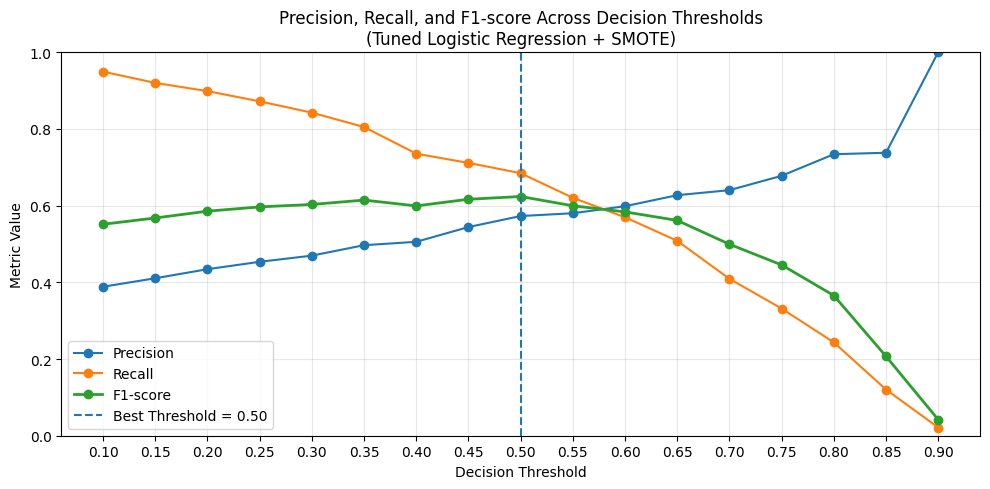


Final Evaluation (Best Threshold Applied):
Best Threshold: 0.5000000000000001

Confusion Matrix (Best Threshold):


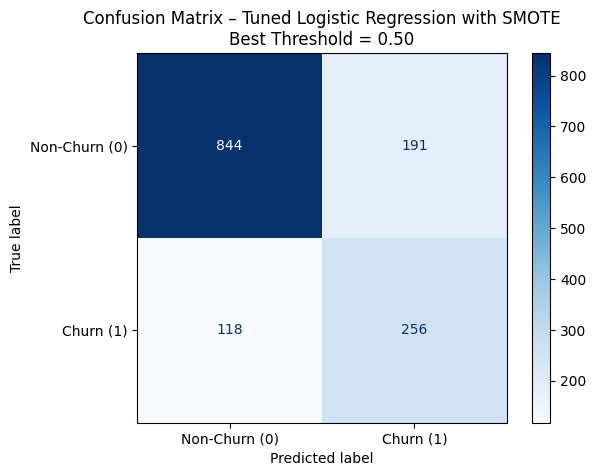


Classification Report (Best Threshold):
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1035
           1       0.57      0.68      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409


Business Lens:
False Negatives (missed churners): 118
False Positives (unnecessary retention): 191


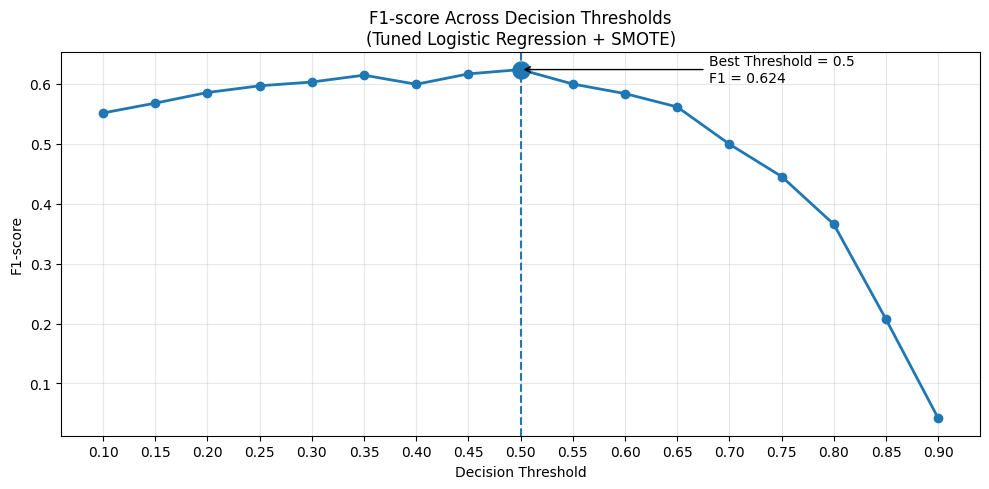

In [103]:
# 6.5 Threshold Optimization (Final Model: Tuned Logistic Regression + SMOTE)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# 1) Get predicted probabilities (positive class = 1)

y_proba_lr = best_lr_model.predict_proba(X_test)[:, 1]

# ROC-AUC stays the same regardless of threshold (uses probabilities)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
print("ROC-AUC (Probabilities):", roc_auc_lr)

# 2) Evaluate a range of thresholds

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for t in thresholds:
    y_pred_thr = (y_proba_lr >= t).astype(int)

    prec = precision_score(y_test, y_pred_thr, zero_division=0)
    rec  = recall_score(y_test, y_pred_thr, zero_division=0)
    f1   = f1_score(y_test, y_pred_thr, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()

    threshold_results.append({
        "Threshold": t,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    })

threshold_df = pd.DataFrame(threshold_results)

# Sort by best F1-score (then higher recall as tie-break)
threshold_df = threshold_df.sort_values(
    by=["F1-score", "Recall"],
    ascending=False
).reset_index(drop=True)

print("\nTop Thresholds (ranked by F1-score):")
display(threshold_df.head(10))

# Best threshold
best_threshold = threshold_df.loc[0, "Threshold"]
best_f1 = threshold_df.loc[0, "F1-score"]
best_recall = threshold_df.loc[0, "Recall"]
best_precision = threshold_df.loc[0, "Precision"]

print(f"\nBest Threshold (by F1-score): {best_threshold:.2f}")
print(f"Precision: {best_precision:.3f} | Recall: {best_recall:.3f} | F1-score: {best_f1:.3f}")

# 3) Plot: Threshold vs Precision / Recall / F1-score
# sort thresholds for smooth plotting
plot_df = threshold_df.sort_values("Threshold") 

plt.figure(figsize=(10,5))

plt.plot(
    plot_df["Threshold"],
    plot_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    plot_df["Threshold"],
    plot_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    plot_df["Threshold"],
    plot_df["F1-score"],
    marker="o",
    linewidth=2,
    label="F1-score"
)

# best threshold line
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.title(
    "Precision, Recall, and F1-score Across Decision Thresholds\n"
    "(Tuned Logistic Regression + SMOTE)"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")

plt.xticks(thresholds)
plt.ylim(0,1)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 4) Apply the best threshold and report final results

y_pred_best_thr = (y_proba_lr >= best_threshold).astype(int)

print("\nFinal Evaluation (Best Threshold Applied):")
print("Best Threshold:", best_threshold)

print("\nConfusion Matrix (Best Threshold):")
cm = confusion_matrix(y_test, y_pred_best_thr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Churn (0)", "Churn (1)"]
)

disp.plot(cmap="Blues", values_format="d")
disp.ax_.set_title(
    f"Confusion Matrix – Tuned Logistic Regression with SMOTE\nBest Threshold = {best_threshold:.2f}"
)

plt.show()

print("\nClassification Report (Best Threshold):")
print(classification_report(y_test, y_pred_best_thr))

# show FN/FP business lens
tn, fp, fn, tp = cm.ravel()
print("\nBusiness Lens:")
print("False Negatives (missed churners):", fn)
print("False Positives (unnecessary retention):", fp)

# 5) F1-score across decision thresholds (Visualization)

dfp = threshold_df.copy()

# round thresholds for clean display
dfp["Threshold"] = dfp["Threshold"].round(2)

# sort thresholds numerically for smooth line
dfp = dfp.sort_values("Threshold")

best_thr = round(best_threshold, 2)
best_f1 = dfp.loc[dfp["Threshold"] == best_thr, "F1-score"].values[0]

plt.figure(figsize=(10,5))

# main line
plt.plot(
    dfp["Threshold"],
    dfp["F1-score"],
    marker="o",
    linewidth=2
)

# highlight best point
plt.scatter(best_thr, best_f1, s=150)

# vertical line for best threshold
plt.axvline(best_thr, linestyle="--")

# annotation (text on the right side of the plot)
plt.annotate(
    f"Best Threshold = {best_thr}\nF1 = {best_f1:.3f}",
    xy=(best_thr, best_f1),              # arrow target
    xytext=(best_thr + 0.18, best_f1),   # text position (right side)
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    va="center"
)

plt.title("F1-score Across Decision Thresholds\n(Tuned Logistic Regression + SMOTE)")
plt.xlabel("Decision Threshold")
plt.ylabel("F1-score")

plt.xticks(dfp["Threshold"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation (Threshold Optimization)**

- The model achieved **ROC-AUC = 0.83**, indicating good ability to separate churn vs. non-churn customers based on predicted probabilities.
- By evaluating multiple decision thresholds (0.10 → 0.90), the best trade-off was achieved at **threshold = 0.50**, where:
  - **Precision = 0.573**, **Recall = 0.684**, **F1-score = 0.624**.
- As the threshold increases, **precision improves** while **recall decreases**. Lower thresholds capture more churners (higher recall) but lead to more unnecessary retention actions (lower precision).
- Using the selected threshold (0.50), the model results indicate:
  - **FN = 118** missed churners
  - **FP = 191** unnecessary retention actions  
  This threshold provides a balanced decision rule, enabling the company to detect a substantial portion of churn customers while avoiding excessive retention costs.
  

### 6.6 Feature Importance

In [104]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": best_lr_model.named_steps["clf"].coef_[0]
})

feature_importance["abs_coef"] = feature_importance["coefficient"].abs()

feature_importance.sort_values("abs_coef", ascending=False).head(10)


,feature,coefficient,abs_coef
2,MonthlyCharges,2.966847,2.966847
7,PhoneService_Yes,-1.373308,1.373308
1,tenure,-1.358287,1.358287
3,TotalCharges,1.030925,1.030925
10,InternetService_Fiber optic,-0.900732,0.900732
25,Contract_Two year,-0.675503,0.675503
13,OnlineSecurity_Yes,-0.559709,0.559709
8,MultipleLines_No phone service,-0.537438,0.537438
19,TechSupport_Yes,-0.518886,0.518886
15,OnlineBackup_Yes,-0.456807,0.456807


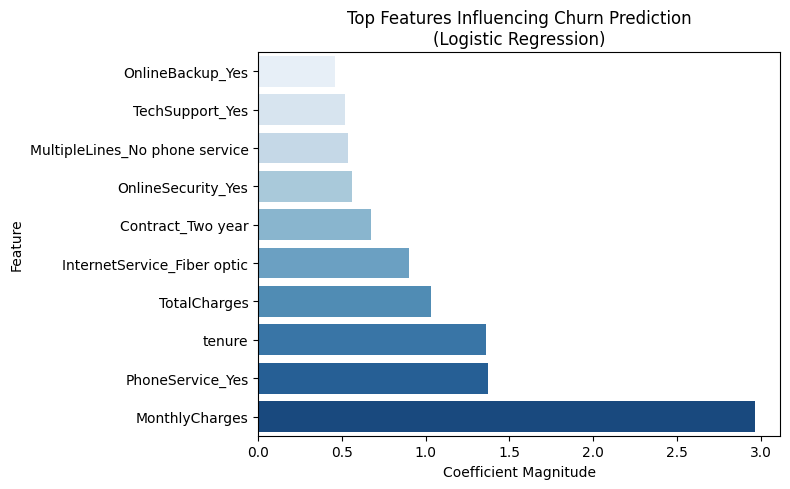

In [105]:

top_features = feature_importance.sort_values("abs_coef", ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_features,
    x="abs_coef",
    y="feature",
    hue="feature",
    palette="Blues_r",
    legend=False
)

plt.gca().invert_yaxis()  

plt.title("Top Features Influencing Churn Prediction\n(Logistic Regression)")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The feature importance analysis highlights the variables that contributed most to the final `tuned Logistic Regression model with SMOTE`, based on the absolute values of the model **coefficients**.

**MonthlyCharges** has the largest **positive coefficient**, indicating that customers with higher monthly charges are more likely to churn. **TotalCharges** and **Fiber Optic Internet Service** are also among the most influential predictors, showing strong associations with churn in the dataset.

In contrast, features such as **tenure** and **Contract_Two year** have **negative coefficients**, suggesting that customers who stay longer or commit to long-term contracts are less likely to churn.

Similarly, value-added services such as **OnlineSecurity, TechSupport, and OnlineBackup** also have **negative coefficients**, indicating that customers using these services tend to have a lower likelihood of churn.

It is important to note that coefficient magnitude reflects the relative influence of each feature on the final model, while the coefficient sign indicates whether the feature increases or decreases the predicted probability of churn. These findings represent statistical associations learned from the data rather than direct causal relationships.

## Step 7: Business Insights & Recommendations

### 7.1 Key Business Insights

The modeling results and feature importance analysis reveal several key factors that significantly influence customer churn behavior.

Among all variables, **MonthlyCharges** appears as the most influential feature, suggesting that customers with higher monthly costs are more likely to discontinue their services. This indicates that pricing plays a critical role in customer retention.

Additionally, **TotalCharges** and **Fiber Optic Internet Service** are among the most influential features associated with churn behavior in the dataset, indicating that these variables play an important role in predicting customer churn. While the model identifies a strong association, it does not determine the underlying cause of this relationship.

In contrast, variables such as **tenure** and **long-term contracts (Contract_Two year)** demonstrate a negative relationship with churn. Customers who stay longer with the company or commit to longer contracts tend to have a lower probability of leaving.

Furthermore, value-added services such as **OnlineSecurity, TechSupport, and OnlineBackup** are associated with lower churn probabilities. Customers using these services tend to be less likely to churn, making them valuable indicators for customer retention strategies.

### 7.2 Customer Risk Segmentation

Although the optimized classification threshold of the final model is **0.50** for predicting churn, the predicted churn probabilities can also be grouped into **business-oriented risk levels** to help organizations identify at-risk customers, prioritize retention efforts, and support decision-making.

* High Risk Customers

   * Customers with **churn probability > 70%** are likely to leave and should be prioritized for retention strategies.

* Medium Risk Customers

   * Customers with **churn probability between 40% and 70%** may require monitoring and targeted engagement.

* Low Risk Customers

   * Customers with **churn probability < 40%** are relatively stable and less likely to churn.

These risk categories are intended for business interpretation and prioritization rather than defining the model's classification threshold.

### 7.3 Business Recommendations

Based on the insights derived from the final predictive model, several actionable strategies can be recommended to reduce customer churn.

- **Pricing Strategy Optimization**

Since **MonthlyCharges** was identified as the most influential predictor in the final model, companies should review pricing strategies and ensure that pricing structures align with perceived customer value. Offering flexible plans or targeted discounts for customers with higher monthly charges may help improve retention.

- **Encouraging Long-Term Contracts**

Customers with **two-year contracts** were associated with lower churn probabilities in the final model. Encouraging customers to transition from month-to-month contracts to longer-term plans through incentives or discounts could help reduce churn risk.

- **Promoting Value-Added Services**

Services such as **OnlineSecurity, TechSupport, and OnlineBackup** were associated with lower churn probabilities in the final model. Bundling these services with core packages or offering promotional trials may encourage customer engagement and improve retention.

- **Targeted Retention Campaigns**

Customers identified as **High Risk** based on the business-oriented risk segmentation should be prioritized for personalized retention campaigns, such as loyalty offers, service upgrades, or proactive customer support interventions.

### 7.4 Business Value of the Predictive Model

The final selected model, `Tuned Logistic Regression with SMOTE`, achieved balanced predictive performance, with an **F1-score of 0.624** and a **ROC-AUC of 0.829**, demonstrating its ability to identify customers who are likely to churn while maintaining a good balance between precision and recall.

By integrating this predictive model into business workflows, organizations can shift from reactive churn management to proactive customer retention strategies. The model enables companies to identify at-risk customers early, prioritize retention efforts, and support data-driven decision-making, ultimately improving customer lifetime value and reducing potential revenue loss.

## Step 8: Saving the Final Model

After selecting `Tuned Logistic Regression with SMOTE` as the final model, the trained model artifacts were saved for deployment.

Since **SMOTE** is only used during training to balance the dataset, it is not required during inference. Therefore, only the components needed for deployment were saved:

- The trained Logistic Regression model
- The fitted StandardScaler
- The feature names in the correct training order

These artifacts will be used later in the Streamlit application to preprocess user input and generate churn predictions consistently.

In [106]:
# Step 8: Save the Final Model for Deployment

import joblib
import os

# Extract trained components from the final pipeline
final_scaler = best_lr_model.named_steps["scaler"]
final_model = best_lr_model.named_steps["clf"]

# Save feature names to preserve column order during deployment
feature_names = X_train.columns.tolist()

# Create folder for saved artifacts
os.makedirs("saved_models", exist_ok=True)

# Save artifacts
joblib.dump(final_model, "saved_models/churn_model.pkl")
joblib.dump(final_scaler, "saved_models/scaler.pkl")
joblib.dump(feature_names, "saved_models/feature_names.pkl")

print("Final model, scaler, and feature names saved successfully.")

Final model, scaler, and feature names saved successfully.


In [107]:
import os

print("Saved files:")
print(os.listdir("saved_models"))

Saved files:
['churn_model.pkl', 'feature_names.pkl', 'scaler.pkl']


## Final Model Summary

After evaluating multiple models and applying **hyperparameter tuning with SMOTE**, `Logistic Regression` was selected as the final model.

**Key Results:**

- ROC-AUC: 0.83  
- Accuracy: 0.78  
- Precision: 0.57  
- Recall: 0.68  
- F1-score: 0.62  
- Optimal Threshold: 0.50  

These results indicate that the model achieves balanced predictive performance while maintaining a strong ability to detect customers at risk of churn.

The model achieves a recall of **0.68**, meaning it correctly identifies approximately **68% of customers who are likely to churn**, providing a useful tool for proactive customer retention strategies.

The trained model was saved along with the preprocessing scaler and feature metadata to ensure consistent predictions during deployment in the Streamlit application.
